In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.portfolio_risk import PortfolioRiskManager

risk_manager = PortfolioRiskManager()

print("PortfolioRiskManager loaded successfully.")

PortfolioRiskManager loaded successfully.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from src.strategies.momentum import MomentumStrategy
from src.strategies.mean_reversion import MeanReversionStrategy
from src.multi_strategy import MultiStrategyEngine
from src.portfolio_risk import PortfolioRiskManager
from src.performance import PerformanceAnalytics

In [4]:
prices = pd.read_csv(
    "../data/raw/daily_prices.csv",
    index_col=0,
    parse_dates=True
)

print("Shape:", prices.shape)
print("Start:", prices.index.min())
print("End:", prices.index.max())

prices.head()

Shape: (6573, 10)
Start: 2000-01-03 00:00:00
End: 2026-02-20 00:00:00


,AAPL,AMZN,GOOGL,JNJ,JPM,KO,MSFT,NVDA,TSLA,XOM
Date,,,,,,,,,,
2000-01-03,0.84,4.47,NaN,23.41,22.91,13.61,35.60,0.09,NaN,17.14
2000-01-04,0.77,4.10,NaN,22.55,22.41,13.63,34.40,0.09,NaN,16.81
2000-01-05,0.78,3.49,NaN,22.79,22.27,13.75,34.76,0.08,NaN,17.73
2000-01-06,0.71,3.28,NaN,23.50,22.59,13.77,33.60,0.08,NaN,18.65
2000-01-07,0.75,3.48,NaN,24.50,23.00,14.67,34.04,0.08,NaN,18.59


In [5]:
strategies = {

    "Momentum": MomentumStrategy(
        lookback=13,
        top_n=3,
        bottom_n=3
    ),

    "Mean Reversion": MeanReversionStrategy(
        lookback=4,
        top_n=3,
        bottom_n=3
    )
}

In [6]:
engine = MultiStrategyEngine(
    strategies=strategies
)

results = engine.run_strategies(
    prices
)

strategy_returns = engine.strategy_returns(
    results
)

strategy_returns.describe()

,Momentum,Mean Reversion
count,1364.000000,1364.000000
mean,0.001871,-0.001285
std,0.042493,0.044194
min,-0.174256,-0.365933
25%,-0.020983,-0.024576
50%,0.001375,-0.001529
75%,0.024969,0.021451
max,0.200475,0.188380


In [7]:
risk_manager = PortfolioRiskManager()

print("PortfolioRiskManager initialized.")

PortfolioRiskManager initialized.


In [8]:
strategy_volatility = (
    risk_manager.annualized_volatility(
        strategy_returns
    )
)

strategy_volatility

Momentum          0.306424
Mean Reversion    0.318687
dtype: float64

In [9]:
covariance_matrix = (
    risk_manager.covariance_matrix(
        strategy_returns
    )
)

covariance_matrix

,Momentum,Mean Reversion
Momentum,0.093896,-0.045027
Mean Reversion,-0.045027,0.101561


In [10]:
equal_weights = (
    risk_manager.equal_weights(
        strategy_returns
    )
)

equal_weights

Momentum          0.5
Mean Reversion    0.5
Name: Equal Weight, dtype: float64

In [11]:
equal_weight_volatility = (
    risk_manager.portfolio_volatility(
        strategy_returns,
        equal_weights
    )
)

print(
    f"Equal-Weight Portfolio Volatility: "
    f"{equal_weight_volatility:.2%}"
)

Equal-Weight Portfolio Volatility: 16.23%


In [12]:
equal_risk_summary = (
    risk_manager.risk_summary(
        strategy_returns,
        equal_weights
    )
)

equal_risk_summary

,Weight,Annual Volatility,Marginal Risk Contribution,Component Risk Contribution,Risk Contribution %
Momentum,0.5,0.306424,0.150523,0.075262,0.463637
Mean Reversion,0.5,0.318687,0.174134,0.087067,0.536363


In [13]:
inverse_vol_weights = (
    risk_manager.inverse_volatility_weights(
        strategy_returns
    )
)

inverse_vol_weights

Momentum          0.509808
Mean Reversion    0.490192
Name: Inverse Volatility Weight, dtype: float64

In [14]:
inverse_vol_risk_summary = (
    risk_manager.risk_summary(
        strategy_returns,
        inverse_vol_weights
    )
)

inverse_vol_risk_summary

,Weight,Annual Volatility,Marginal Risk Contribution,Component Risk Contribution,Risk Contribution %
Momentum,0.509808,0.306424,0.159062,0.081091,0.5
Mean Reversion,0.490192,0.318687,0.165427,0.081091,0.5


In [15]:
inverse_vol_portfolio_vol = (
    risk_manager.portfolio_volatility(
        strategy_returns,
        inverse_vol_weights
    )
)

print(
    f"Inverse-Volatility Portfolio Volatility: "
    f"{inverse_vol_portfolio_vol:.2%}"
)

Inverse-Volatility Portfolio Volatility: 16.22%


In [16]:
equal_diversification = (
    risk_manager.diversification_ratio(
        strategy_returns,
        equal_weights
    )
)

inverse_diversification = (
    risk_manager.diversification_ratio(
        strategy_returns,
        inverse_vol_weights
    )
)

print(
    f"Equal-Weight Diversification Ratio: "
    f"{equal_diversification:.3f}"
)

print(
    f"Inverse-Vol Diversification Ratio: "
    f"{inverse_diversification:.3f}"
)

Equal-Weight Diversification Ratio: 1.925
Inverse-Vol Diversification Ratio: 1.926


In [17]:
equal_weight_returns = (
    risk_manager.portfolio_returns(
        strategy_returns,
        equal_weights
    )
)

inverse_vol_returns = (
    risk_manager.portfolio_returns(
        strategy_returns,
        inverse_vol_weights
    )
)

In [18]:
portfolio_returns = pd.DataFrame({
    "Equal Weight": equal_weight_returns,
    "Inverse Volatility": inverse_vol_returns
})

portfolio_returns.head()

,Equal Weight,Inverse Volatility
Date,,
2000-01-07,0.0,0.0
2000-01-14,0.0,0.0
2000-01-21,0.0,0.0
2000-01-28,0.0,0.0
2000-02-04,0.0,0.0


In [19]:
performance = PerformanceAnalytics()

comparison = []

for name in portfolio_returns.columns:

    returns = portfolio_returns[name]

    comparison.append({

        "Portfolio": name,

        "Annual Return":
            performance.annual_return(
                returns
            ),

        "Annual Volatility":
            performance.annual_volatility(
                returns
            ),

        "Sharpe Ratio":
            performance.sharpe_ratio(
                returns
            ),

        "Maximum Drawdown":
            performance.max_drawdown(
                returns
            ),

        "Win Rate":
            performance.win_rate(
                returns
            )
    })

portfolio_comparison = (
    pd.DataFrame(comparison)
    .set_index("Portfolio")
)

portfolio_comparison

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown,Win Rate
Portfolio,,,,,
Equal Weight,0.001899,0.162329,0.011701,-0.453205,0.493402
Inverse Volatility,0.003545,0.162182,0.021855,-0.446724,0.502933


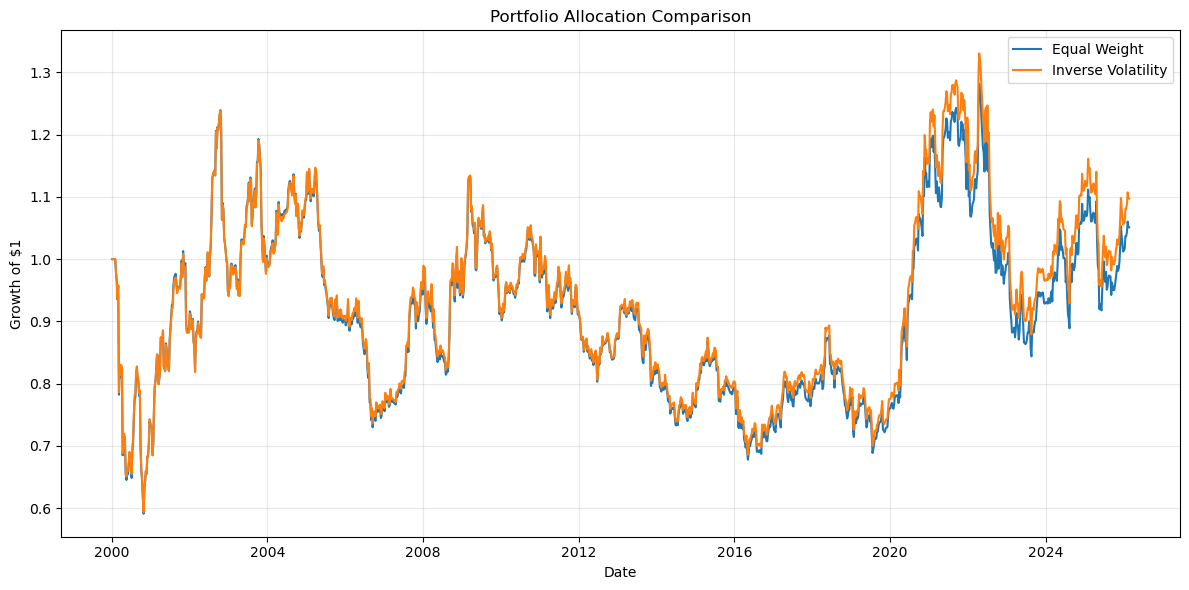

In [20]:
cumulative = (
    1 + portfolio_returns.fillna(0)
).cumprod()

plt.figure(figsize=(12, 6))

for column in cumulative.columns:

    plt.plot(
        cumulative.index,
        cumulative[column],
        label=column
    )

plt.title(
    "Portfolio Allocation Comparison"
)

plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [21]:
risk_contributions = pd.DataFrame({

    "Equal Weight":
        risk_manager.percentage_risk_contribution(
            strategy_returns,
            equal_weights
        ),

    "Inverse Volatility":
        risk_manager.percentage_risk_contribution(
            strategy_returns,
            inverse_vol_weights
        )
})

risk_contributions

,Equal Weight,Inverse Volatility
Momentum,0.463637,0.5
Mean Reversion,0.536363,0.5


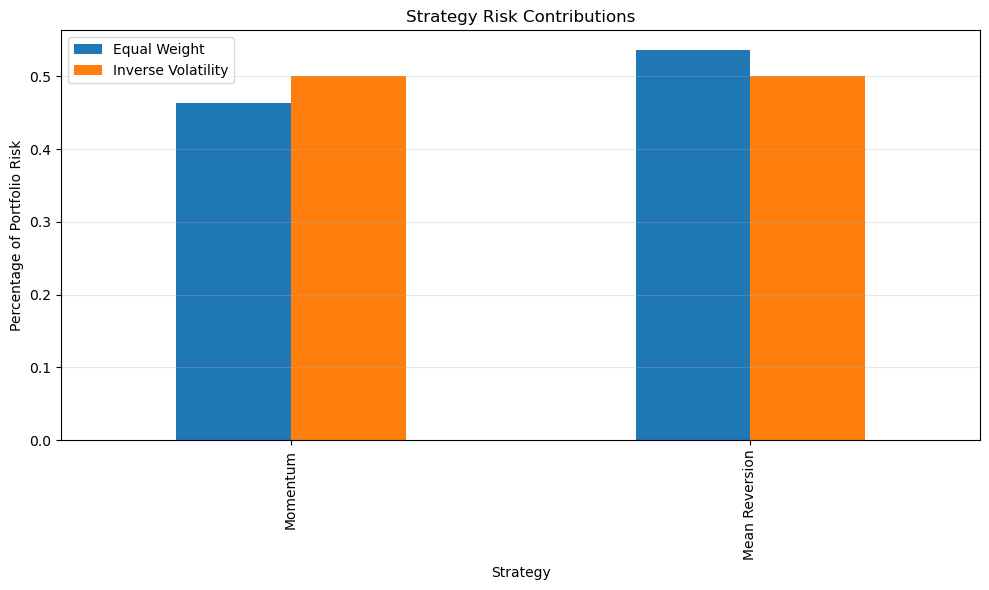

In [22]:
risk_contributions.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Strategy Risk Contributions"
)

plt.ylabel(
    "Percentage of Portfolio Risk"
)

plt.xlabel("Strategy")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [23]:
from pathlib import Path

results_dir = Path("../results")

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

portfolio_comparison.to_csv(
    results_dir /
    "portfolio_risk_performance.csv"
)

equal_risk_summary.to_csv(
    results_dir /
    "equal_weight_risk_summary.csv"
)

inverse_vol_risk_summary.to_csv(
    results_dir /
    "inverse_volatility_risk_summary.csv"
)

risk_contributions.to_csv(
    results_dir /
    "strategy_risk_contributions.csv"
)

portfolio_returns.to_csv(
    results_dir /
    "risk_managed_portfolio_returns.csv"
)

print(
    "Module 17 results saved successfully."
)

Module 17 results saved successfully.
